In [17]:
import pandas
import sqlalchemy
import matplotlib.pyplot as plt

In [18]:
engine = sqlalchemy.create_engine('sqlite:///../power.db')

In [19]:
sql = "SELECT timestamp, power FROM pv WHERE timestamp > '2000-04-12 08:00'"
df = pandas.read_sql(sql, engine)
df['timestamp'] = pandas.to_datetime(df['timestamp'], format='ISO8601')
df.set_index('timestamp', inplace=True)

In [22]:
df

,power
timestamp,
2026-04-13 18:47:52.534732-07:00,0.000
2026-04-13 18:48:17.443186-07:00,0.000
2026-04-13 18:55:21.990712-07:00,1.903
2026-04-13 18:55:26.003345-07:00,1.903
2026-04-13 18:55:33.333406-07:00,0.000
...,...
2026-04-14 11:23:28.709975-07:00,45.998
2026-04-14 11:24:18.671550-07:00,46.393
2026-04-14 11:25:16.212720-07:00,49.307


<Axes: xlabel='timestamp'>

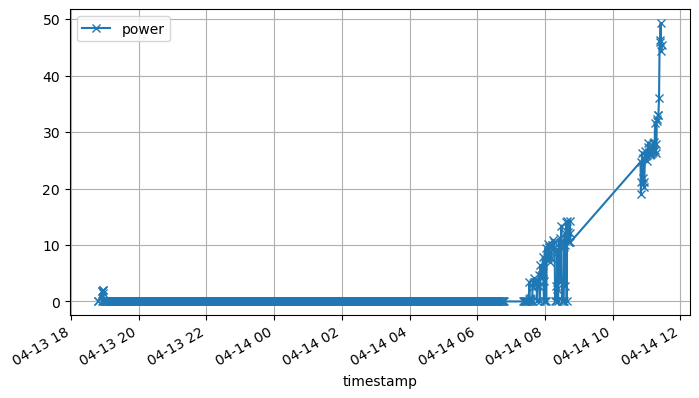

In [20]:
fig, ax = plt.subplots(figsize=(8, 4.5))
df.plot(ax=ax, grid=True, marker='x')

In [21]:
# Take 15 minute averages, sum them up and divide by 4
energy = df.resample('15min').mean()['power'].sum() / 4
energy

np.float64(31.632471336996336)

# Alltime

In [7]:
df_all = pandas.read_sql("select timestamp, power from pv where timestamp>'2026-04-01'", engine)
df_all['timestamp'] = pandas.to_datetime(df_all['timestamp'], format='ISO8601')
df_all.set_index('timestamp', inplace=True)

<Axes: xlabel='hour_of_day'>

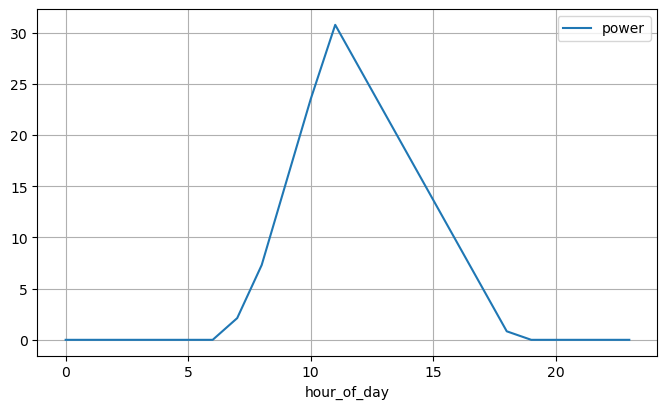

In [8]:
fig, ax = plt.subplots(figsize=(8, 4.5))

df_all['hour_of_day'] = df_all.index.hour
df_all.groupby('hour_of_day').mean().plot(ax=ax, grid=True)

In [9]:
df_all['15_min_chunk'] = (df_all.index.hour * 60 + df_all.index.minute) // 15

Text(0, 0.5, 'Energy in kWh')

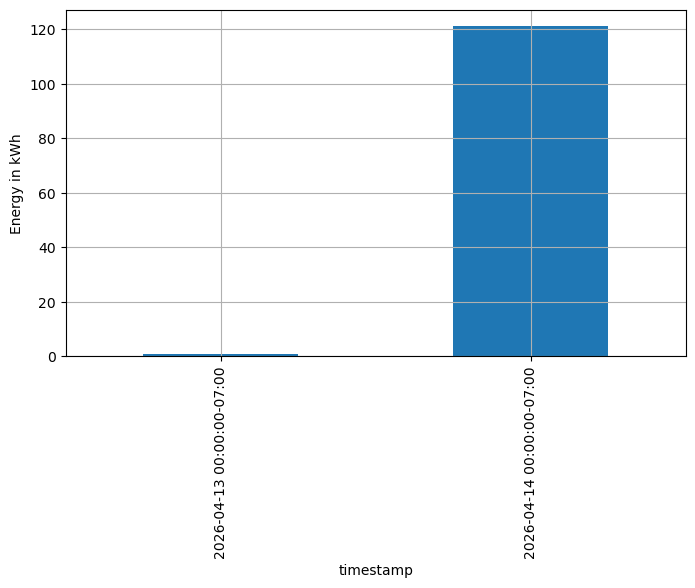

In [10]:
fig, ax = plt.subplots(figsize=(8, 4.5))

(df_all['power'].resample('1D').sum()/12).plot.bar(ax=ax, grid=True)
ax.set_ylabel("Energy in kWh")

Text(0, 0.5, 'Energy in kWh')

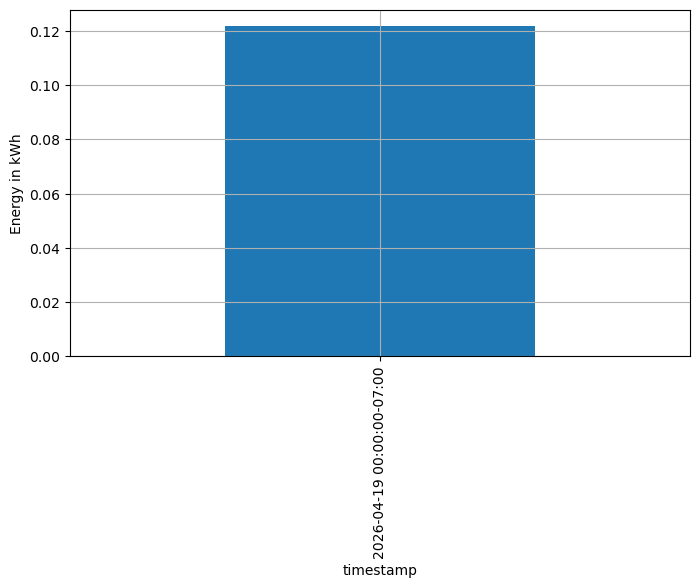

In [11]:
fig, ax = plt.subplots(figsize=(8, 4.5))

(df_all['power'].resample('1W').sum()/12/1000).plot.bar(ax=ax, grid=True)
ax.set_ylabel("Energy in kWh")

Text(0, 0.5, 'Energy in kWh')

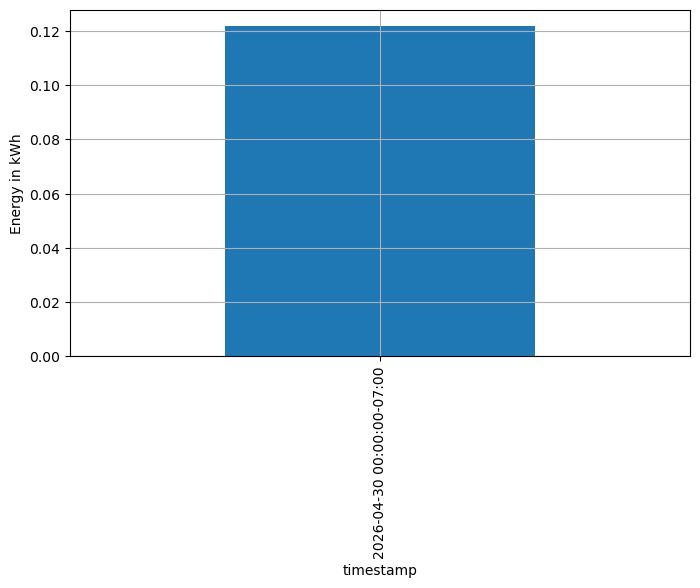

In [13]:
fig, ax = plt.subplots(figsize=(8, 4.5))

(df_all['power'].resample('1ME').sum()/12/1000).plot.bar(ax=ax, grid=True)
ax.set_ylabel("Energy in kWh")

In [15]:
energy = df_all.resample('15min').mean()['power'].sum() / 4
energy / 1000

np.float64(0.03128251504329004)